# ALSRS — Final Irrigation-Need Model (Cacao CCN-51)

Self-contained notebook that trains, evaluates and saves the **final
recommended** Random Forest model that predicts irrigation need from water
deficit. Run every cell top to bottom.

## Final configuration (from `evaluate_model.py`, experiments A-D)

| choice | value | why |
|---|---|---|
| estimator | `RandomForestRegressor` | robust, no scaling, good on tabular data |
| `n_estimators` | `300` | B: 300 ~= 500 (RMSE 12.76 vs 12.75) at half the cost |
| `max_depth` | `None` | B: full depth wins; `d=10` collapses to RMSE ~14 |
| `min_samples_leaf` | `1` | B: leaf=1 beats leaf=5 |
| `sample_weight` | `linear` (deficit) | A: best recall of HIGH / NOT_SUITABLE |
| split | by farm, 80/20, seed 42 | no leakage between a farm's rows |

## What this notebook does

1. Load `ml_dataset_cacao_ccn51.csv`.
2. Split by **farm** (never inside a farm) so evaluation is honest.
3. Train **3 independent models** (one per horizon: 1 / 3 / 6 months).
4. Report holdout + 5-fold CV metrics against 3 baselines.
5. Inspect feature importance.
6. Save the 3 trained models for reuse.


In [1]:
# -----------------------------------------------------------------------------
# 1. Imports
# -----------------------------------------------------------------------------
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Random Forest, model selection and metrics.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save / reload the trained models.
import joblib

print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 2.3.3 | numpy 2.2.6


In [2]:
# -----------------------------------------------------------------------------
# 2. Dataset + schema
# -----------------------------------------------------------------------------
# The notebook lives in ml/; resolve that directory robustly.
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"

df = pd.read_csv(DATASET)
print("Dataset:", DATASET.name, f"({df.shape[0]} rows x {df.shape[1]} cols)")
print("Farms (point_id):", df["point_id"].nunique())

# Features: variables known AT time t only (no future information is leaked).
FEATURES = [
    "month", "biweek",          # seasonality (position in the year)
    "mean_C", "std_C",          # temperature
    "precip_total_mm", "precip_rainy_days", "pet_mm",   # water supply / demand
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",        # drought index
    "AWC_mm", "Storage_mm", "P_acum_mm",                # soil water balance
    "WRSI_1m", "deficit_1m",    # current water stress
    "oni",                      # ENSO climate index (NOAA CPC)
]

# Targets: deficit accumulated over the NEXT 1 / 3 / 6 months (0-100%).
# These are the three nested horizons we forecast.
TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# Irrigation-need classes (thresholds 15 / 30 / 50 from the water-balance module).
SEVERITY = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "NOT_SUITABLE": 3}

# FINAL RECOMMENDED configuration (experiments A + B).
FINAL_CONFIG = dict(
    n_estimators=300,     # B: 300 ~= 500 but ~2x faster
    max_depth=None,       # B: full depth wins (d=10 collapses to RMSE ~14)
    min_samples_leaf=1,   # B: leaf=1 wins
    random_state=42,      # reproducibility
    n_jobs=-1,            # use all CPU cores
)


Dataset: ml_dataset_cacao_ccn51.csv (52341 rows x 33 cols)
Farms (point_id): 239


## 3. Split by farm (not by row)

Rows of the same farm (`point_id`) form a time series: one month's deficit is
correlated with the next. A random row split would let the model see part of a
farm in training and the rest in test, which leaks information and inflates the
score. So we split the list of **farms** 80/20 (seed 42): each farm lands
entirely in train or entirely in test.


In [3]:
# Split the fararms (not rows) 80/20 with a fixed seed for reproducibility.
point_ids = df["point_id"].unique()
train_pts, test_pts = train_test_split(point_ids, test_size=0.20, random_state=42)

tr = df[df["point_id"].isin(train_pts)].copy()
te = df[df["point_id"].isin(test_pts)].copy()

print(f"Train farms: {len(train_pts):4d}  ({len(tr):6d} rows)")
print(f"Test  farms: {len(test_pts):4d}  ({len(te):6d} rows)")


Train farms:  191  ( 41829 rows)
Test  farms:   48  ( 10512 rows)


## 4. Sample weight = deficit (linear)

The target is zero-inflated: many periods have `future_deficit = 0` (no
irrigation needed) and those rows dominate the loss. With
`sample_weight = deficit`, a 0-deficit row contributes weight 0 (ignored) and
the model focuses on the rows that actually need irrigation - which is exactly
the decision we care about. Experiment A confirmed `linear` is best:

| weight | recall HIGH | recall NOT_SUITABLE |
|---|---|---|
| linear | **0.461** | **0.674** |
| squared | 0.449 | 0.652 |
| plus1sq | 0.288 | 0.606 |


In [4]:
# -----------------------------------------------------------------------------
# Helpers (weight, metrics, class mapping)
# -----------------------------------------------------------------------------
def weight_linear(deficit):
    "weight = deficit: 0-deficit rows are ignored, the tail dominates the fit."
    return deficit


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def classify_deficit(v):
    "Map a deficit percentage to its irrigation-need class (thresholds 15/30/50)."
    if pd.isna(v):
        return "NA"
    if v <= 15:
        return "LOW"
    if v <= 30:
        return "MEDIUM"
    if v <= 50:
        return "HIGH"
    return "NOT_SUITABLE"


def worst_of(*classes):
    "Most severe class among the 3 horizons (the final suggestion)."
    return max(classes, key=lambda c: SEVERITY.get(c, -1))


def make_model():
    "Build a fresh Random Forest with the FINAL recommended configuration."
    return RandomForestRegressor(**FINAL_CONFIG)


## 5. Train the 3 final models

One independent `RandomForestRegressor` per horizon (1 / 3 / 6 months), each
trained with `sample_weight = linear(deficit)` on the SAME training farms.


In [5]:
models = {}
holdout = {}

for target in TARGETS:
    model = make_model()
    w = weight_linear(tr[target])
    model.fit(tr[FEATURES], tr[target], sample_weight=w)
    pred = model.predict(te[FEATURES])

    models[target] = model
    holdout[target] = {
        "mae": mean_absolute_error(te[target], pred),
        "rmse": rmse(te[target], pred),
        "r2": r2_score(te[target], pred),
    }
    print(f"{target:<24} MAE={holdout[target]['mae']:6.2f}  "
          f"RMSE={holdout[target]['rmse']:6.2f}  R2={holdout[target]['r2']:6.3f}")


future_deficit_1m        MAE= 11.59  RMSE= 14.11  R2= 0.719
future_deficit_3m        MAE= 10.88  RMSE= 12.91  R2= 0.641
future_deficit_6m        MAE= 10.87  RMSE= 13.54  R2= 0.338


In [6]:
# Interpret the regression in irrigation terms: recall of the severe classes.
# The final suggestion is the WORST class across the 3 predicted horizons.
true_cls = te[TARGETS].map(classify_deficit)
pred_cls = pd.DataFrame({
    t: pd.Series(models[t].predict(te[FEATURES]), index=te.index).map(classify_deficit)
    for t in TARGETS
})
true_sugg = true_cls.apply(lambda r: worst_of(*r), axis=1)
pred_sugg = pred_cls.apply(lambda r: worst_of(*r), axis=1)

for cls in ["HIGH", "NOT_SUITABLE"]:
    mask = true_sugg == cls
    recall = (pred_sugg[mask] == cls).mean() if mask.sum() else float("nan")
    print(f"recall {cls:<13}: {recall:.3f}")


recall HIGH         : 0.461
recall NOT_SUITABLE : 0.674


## 6. Robust metric - 5-fold cross-validation by farm

A single 80/20 holdout is one lucky (or unlucky) sample. For the official
number we run 5-fold `GroupKFold` grouped by `point_id`, so no farm is ever in
both train and test. We compare against 3 honest baselines on the SAME folds:

- **persist**: predict the same-sized deficit from just before t
  (1m -> `deficit_1m`, 3m -> `past_deficit_3m`, 6m -> `past_deficit_6m`).
- **mean / median**: always predict the training fold's mean / median.

R2 is shown for reference only - it is unreliable on zero-inflated targets.


In [7]:
# Same-window persistence baseline for each horizon (honest, matched window).
PERSIST_COL = {
    "future_deficit_1m": "deficit_1m",
    "future_deficit_3m": "past_deficit_3m",
    "future_deficit_6m": "past_deficit_6m",
}


def cv_eval(target):
    gkf = GroupKFold(n_splits=5)
    maes, rmses = [], []
    p_maes, p_rmses = [], []
    for tr_idx, va_idx in gkf.split(df, groups=df["point_id"]):
        Xtr, ytr = df.iloc[tr_idx][FEATURES], df.iloc[tr_idx][target]
        Xva, yva = df.iloc[va_idx][FEATURES], df.iloc[va_idx][target]

        m = make_model()
        m.fit(Xtr, ytr, sample_weight=weight_linear(ytr))
        pred = m.predict(Xva)
        maes.append(mean_absolute_error(yva, pred))
        rmses.append(rmse(yva, pred))

        # Persistence: read from the full df (past_deficit_* are not features).
        persist = df.iloc[va_idx][PERSIST_COL[target]]
        valid = persist.notna() & yva.notna()   # early rows have no full window
        p_maes.append(mean_absolute_error(yva[valid], persist[valid]))
        p_rmses.append(rmse(yva[valid], persist[valid]))

    return dict(
        model_mae=float(np.mean(maes)), model_rmse=float(np.mean(rmses)),
        persist_mae=float(np.mean(p_maes)), persist_rmse=float(np.mean(p_rmses)),
    )


for target in TARGETS:
    r = cv_eval(target)
    print(f"{target:<24} model MAE={r['model_mae']:6.2f} RMSE={r['model_rmse']:6.2f}  "
          f"| persist MAE={r['persist_mae']:6.2f} RMSE={r['persist_rmse']:6.2f}")


future_deficit_1m        model MAE= 11.21 RMSE= 13.81  | persist MAE= 10.80 RMSE= 22.49
future_deficit_3m        model MAE= 11.00 RMSE= 12.84  | persist MAE= 15.85 RMSE= 25.70
future_deficit_6m        model MAE= 10.60 RMSE= 12.76  | persist MAE= 14.34 RMSE= 20.00


## 7. Feature importance

Random Forest reports how much each feature reduces the error (higher = more
useful). We average the importance across the 3 horizons.


P_acum_mm            0.1759
month                0.1747
Storage_mm           0.0839
AWC_mm               0.0799
mean_C               0.0678
spei_1m              0.0617
oni                  0.0597
pet_mm               0.0560
spei_12m             0.0441
spei_6m              0.0394
spei_3m              0.0383
std_C                0.0376
precip_total_mm      0.0218
biweek               0.0154
deficit_1m           0.0151
WRSI_1m              0.0149
precip_rainy_days    0.0140
Name: mean, dtype: float64


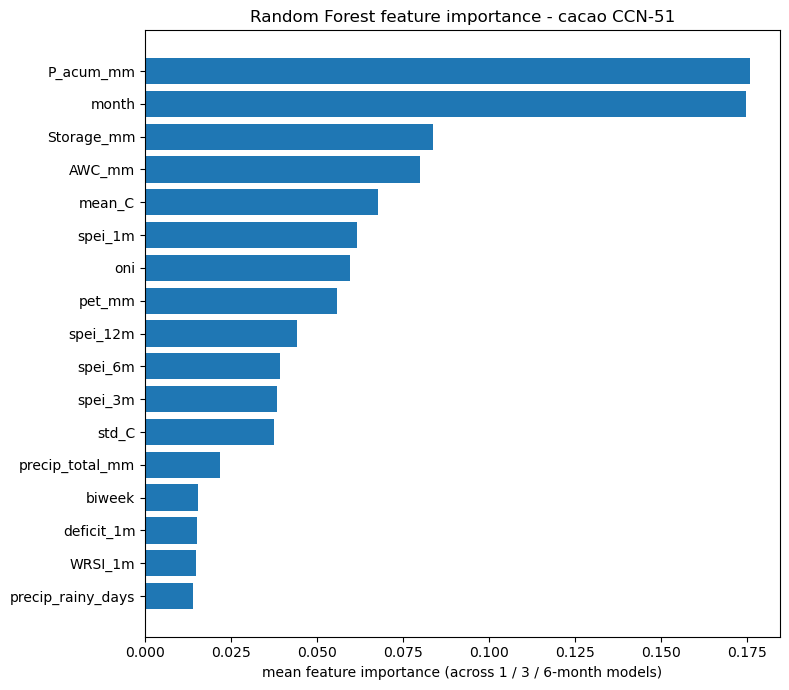

In [8]:
imp = pd.DataFrame({t: models[t].feature_importances_ for t in TARGETS}, index=FEATURES)
imp["mean"] = imp.mean(axis=1)
imp = imp.sort_values("mean", ascending=False)

print(imp["mean"].round(4))

plt.figure(figsize=(8, 7))
plt.barh(imp.index[::-1], imp["mean"][::-1])
plt.xlabel("mean feature importance (across 1 / 3 / 6-month models)")
plt.title("Random Forest feature importance - cacao CCN-51")
plt.tight_layout()
plt.show()


## 8. Save the trained models

For the deployed model we retrain on the **full dataset** (all farms), so the
final model sees every example. The metric to quote is the 5-fold CV above; the
saved model is the one you would use to make predictions. Models are written
with `joblib` (fast to load, keeps the whole forest intact).


In [9]:
MODEL_DIR = ML_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_models = {}
for target in TARGETS:
    m = make_model()
    m.fit(df[FEATURES], df[target], sample_weight=weight_linear(df[target]))
    path = MODEL_DIR / f"rf_{target}.joblib"
    joblib.dump(m, path)
    final_models[target] = path.name

# Manifest with the exact schema + config, so loading later is unambiguous.
manifest = {
    "crop": "cacao_ccn51",
    "features": FEATURES,
    "targets": TARGETS,
    "config": FINAL_CONFIG,
    "weight": "linear",
    "models": final_models,
}
with open(MODEL_DIR / "manifest.json", "w") as fh:
    json.dump(manifest, fh, indent=2)

print("Saved to", MODEL_DIR)
print(json.dumps(manifest, indent=2))


Saved to /home/wmlegion/Documents/github/ALSRS/ml/models
{
  "crop": "cacao_ccn51",
  "features": [
    "month",
    "biweek",
    "mean_C",
    "std_C",
    "precip_total_mm",
    "precip_rainy_days",
    "pet_mm",
    "spei_1m",
    "spei_3m",
    "spei_6m",
    "spei_12m",
    "AWC_mm",
    "Storage_mm",
    "P_acum_mm",
    "WRSI_1m",
    "deficit_1m",
    "oni"
  ],
  "targets": [
    "future_deficit_1m",
    "future_deficit_3m",
    "future_deficit_6m"
  ],
  "config": {
    "n_estimators": 300,
    "max_depth": null,
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1
  },
  "weight": "linear",
  "models": {
    "future_deficit_1m": "rf_future_deficit_1m.joblib",
    "future_deficit_3m": "rf_future_deficit_3m.joblib",
    "future_deficit_6m": "rf_future_deficit_6m.joblib"
  }
}


## 9. How to load and predict

Later (e.g. in the report or a service) load a model with `joblib` and call
`.predict()` on a row of the 17 features. The final `suggestion` is the worst
class across the 3 horizons.


In [ ]:
# Minimal usage example: reload a model and predict one row.
demo = joblib.load(MODEL_DIR / "rf_future_deficit_6m.joblib")
row = df[FEATURES].iloc[:1]          # a real feature row
print("Predicted 6-month deficit (%):", round(float(demo.predict(row)[0]), 1))


## Summary

- **Final model:** `RandomForestRegressor(n_estimators=300, max_depth=None,
  min_samples_leaf=1)` with `sample_weight = deficit`.
- **Official metrics (5-fold CV by farm):** MAE ~= 10.6-11.2, RMSE ~= 12.8-13.8.
- **Beats persistence** clearly at the 3- and 6-month horizons - the decision
  window that matters for planning irrigation.
- **Saved models:** `ml/models/rf_future_deficit_1m/3m/6m.joblib` + `manifest.json`.
